# Retrieval-Augmented Generation (RAG) — In-Depth Engineering Guide (Explained)

## 1. What is RAG (Simple but Precise)

RAG is a system that makes an AI model **read from external data before answering**.

Instead of guessing from training, the model:

1. Searches for relevant information
2. Uses that information to generate the answer

Think of it as:

* LLM = brain
* Retriever = search engine
* RAG = brain + search engine

---

## 2. Why RAG is Important

### Problem with LLMs

* Knowledge is frozen at training time
* Can hallucinate (confidently wrong answers)
* Cannot access private/company data

### What RAG Fixes

* Adds **real-time knowledge**
* Grounds answers in **actual documents**
* Works with **internal/private data**

---

## 3. High-Level Flow (Step-by-Step)

1. User asks a question
2. System converts question → vector (embedding)
3. Search similar vectors in database
4. Retrieve top relevant documents
5. Inject them into prompt
6. LLM generates grounded answer

If retrieval is bad → answer is bad (critical insight)

---

## 4. System Architecture (Explained)

### 4.1 Embedding Model

Converts text into numbers (vectors)

Why?
Because machines compare numbers, not text.

Example:
"apple fruit" and "banana" → close vectors
"apple company" → different vector

---

### 4.2 Vector Database

Stores embeddings and allows fast similarity search

Examples:

* FAISS (local, fast)
* Pinecone (managed)
* Weaviate

Key idea:
Instead of exact match → we do **semantic search**

---

### 4.3 Retriever

Finds top-K similar chunks

Important tuning:

* K too small → miss info
* K too large → noise

---

### 4.4 Re-ranker (Advanced but Important)

Improves quality by reordering results

Why?
Vector search is approximate

Re-ranker = more precise but slower

---

### 4.5 LLM (Generator)

Takes:

* User query
* Retrieved context

Produces:

* Final answer grounded in context

---

### 4.6 Orchestrator

The "brain of the system"

Handles:

* Pipeline flow
* Retries
* Prompt building
* Error handling

---

## 5. Indexing Pipeline (Offline Phase)

This is where most beginners fail.

### 5.1 Data Preparation

* Clean text
* Remove duplicates
* Add metadata (source, date, etc.)

---

### 5.2 Chunking (VERY IMPORTANT)

Split documents into smaller parts

Why?
LLMs and embeddings work better on smaller chunks

Strategies:

1. Fixed chunk (simple)
2. Overlapping chunk (better recall)
3. Semantic chunking (best quality)

Tradeoff:

* Small chunk → better search
* Large chunk → better context

---

### 5.3 Embedding Generation

Each chunk → vector

Important:

* Use same embedding model for query + documents

---

### 5.4 Indexing

Store vectors in efficient structure:

* HNSW → best balance
* IVF → scalable
* PQ → memory optimized

---

## 6. Retrieval Phase (Runtime)

### 6.1 Similarity Search

We compare:
Query vector vs document vectors

Metrics:

* Cosine similarity (most common)
* Dot product

---

### 6.2 Retrieval Techniques

1. Top-K (basic)
2. MMR (reduce duplicates)
3. Hybrid search (vector + keyword)

Hybrid search = **production best practice**

---

### 6.3 Query Improvement (Advanced)

* Rewrite query
* Expand query
* Generate multiple queries

This improves recall significantly

---

## 7. Context Construction (Critical Step)

We build the prompt like this:

Context:
[retrieved documents]

Question:
[user query]

Rules:

* Answer only from context

---

### Optimization Techniques

* Remove duplicate info
* Keep most relevant first
* Fit within token limit

---

## 8. Generation Phase

LLM generates answer using context

Key idea:
LLM is not searching anymore → just reasoning over given data

---

## 9. Evaluation (How You Know It Works)

### Retrieval Metrics

* Recall@K → did we fetch correct doc?
* Precision@K → how many results are useful?

### Generation Metrics

* Faithfulness → is answer grounded?
* Relevance → does it answer question?

---

## 10. Optimization (Real Engineering Work)

### Improve Quality

* Better chunking
* Better embeddings
* Add re-ranking

### Improve Latency

* Cache embeddings
* Reduce K
* Use faster models

### Reduce Cost

* Smaller models
* Fewer tokens

---

## 11. Failure Modes

1. Retrieval miss → wrong answer
2. Too much context → confusion
3. Hallucination
4. Bad chunking

Fixes:

* Increase K
* Use hybrid search
* Improve chunking

---

## 12. RAG Variants

### Naive RAG

Retrieve → generate

### Advanced RAG

* Re-ranking
* Query rewriting

### Agentic RAG

* Multi-step reasoning
* Iterative retrieval

---

## 13. RAG vs Fine-Tuning

RAG:

* Dynamic knowledge
* Uses external data

Fine-tuning:

* Static knowledge
* Changes model behavior

Best practice: combine both

---

## 14. Simple Code Flow

```python
async def rag_pipeline(query):
    q_vec = embed(query)

    docs = vector_db.search(q_vec, top_k=10)

    reranked = rerank(query, docs)

    context = build_context(reranked[:5])

    response = llm.generate(
        prompt=template(context, query)
    )

    return response
```

---

## 15. System Design (Interview Level)

* Use async pipelines (FastAPI)
* Add caching (Redis)
* Use vector DB (FAISS/Pinecone)
* Add observability (logs + tracing)

---

## 16. Critical Insights (Top 1%)

* Retrieval quality > model quality
* Chunking is a first-order problem
* Re-ranking gives biggest improvement
* Observability is mandatory

---

## 17. Final Mental Model

RAG = Search System + Context Builder + LLM

If search fails → everything fails

---

## 18. End-to-End RAG Architecture Diagram

### 18.1 High-Level Architecture

```plaintext
                ┌──────────────────────┐
                │      User / Client   │
                └─────────┬────────────┘
                          │ HTTP Request
                          ▼
                ┌──────────────────────┐
                │   FastAPI Backend    │
                │  (Orchestrator)      │
                └─────────┬────────────┘
                          │
        ┌─────────────────┼─────────────────┐
        │                 │                 │
        ▼                 ▼                 ▼
┌──────────────┐  ┌──────────────┐  ┌──────────────┐
│ Embedding    │  │  Cache Layer │  │  Logging &   │
│ Service      │  │  (Redis)     │  │ Observability│
└──────┬───────┘  └──────┬───────┘  └──────────────┘
       │                 │
       ▼                 ▼
┌────────────────────────────────────┐
│        Vector Database             │
│   (FAISS / Pinecone / Weaviate)    │
└──────────────┬─────────────────────┘
               │ Top-K Results
               ▼
        ┌──────────────┐
        │  Re-Ranker   │
        └──────┬───────┘
               │ Top-N
               ▼
        ┌──────────────┐
        │ Context      │
        │ Builder      │
        └──────┬───────┘
               │ Prompt
               ▼
        ┌──────────────┐
        │     LLM      │
        │ (Generator)  │
        └──────┬───────┘
               │
               ▼
        ┌──────────────┐
        │ Final Answer │
        └──────────────┘
```

---

### 18.2 Data Ingestion Pipeline (Offline)

```plaintext
        ┌──────────────────────┐
        │   Data Sources       │
        │ (PDFs, DB, APIs)    │
        └─────────┬────────────┘
                  ▼
        ┌──────────────────────┐
        │ Data Cleaning        │
        └─────────┬────────────┘
                  ▼
        ┌──────────────────────┐
        │ Chunking             │
        │ (overlap/semantic)   │
        └─────────┬────────────┘
                  ▼
        ┌──────────────────────┐
        │ Embedding Generation │
        └─────────┬────────────┘
                  ▼
        ┌──────────────────────┐
        │ Vector DB Indexing   │
        └──────────────────────┘
```

---

### 18.3 Request Lifecycle (Step-by-Step)

1. User sends query → FastAPI
2. Check cache (optional)
3. Generate query embedding
4. Retrieve Top-K documents from vector DB
5. Re-rank results (optional but important)
6. Build prompt (context + query)
7. Send to LLM
8. Return response
9. Cache result (optional)

---

### 18.4 Production Concerns (Where Systems Fail)

#### Latency Bottlenecks

* Embedding API calls
* Vector search (large index)
* LLM response time

#### Scaling Strategy

* Horizontal scaling for API (Kubernetes)
* Sharded vector DB
* Async pipelines (very important)

#### Reliability

* Retry failed embedding/LLM calls
* Fallback to simpler retrieval
* Circuit breakers

---

### 18.5 Interview Insight

If you explain this diagram clearly, you demonstrate:

* Backend architecture understanding
* Distributed systems thinking
* AI system design maturity

---

## 19. What You Should Do Next

1. Build simple RAG (FAISS + FastAPI)
2. Add re-ranking
3. Add evaluation metrics
4. Add caching + monitoring

---

This architecture is exactly what production-grade RAG systems look like.


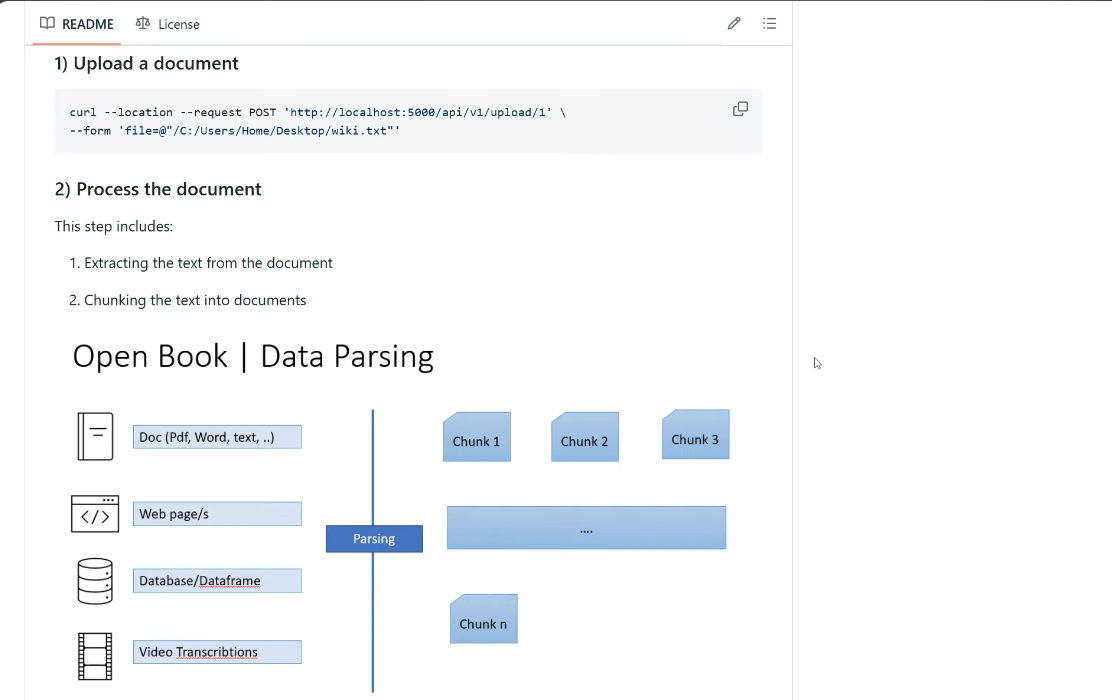

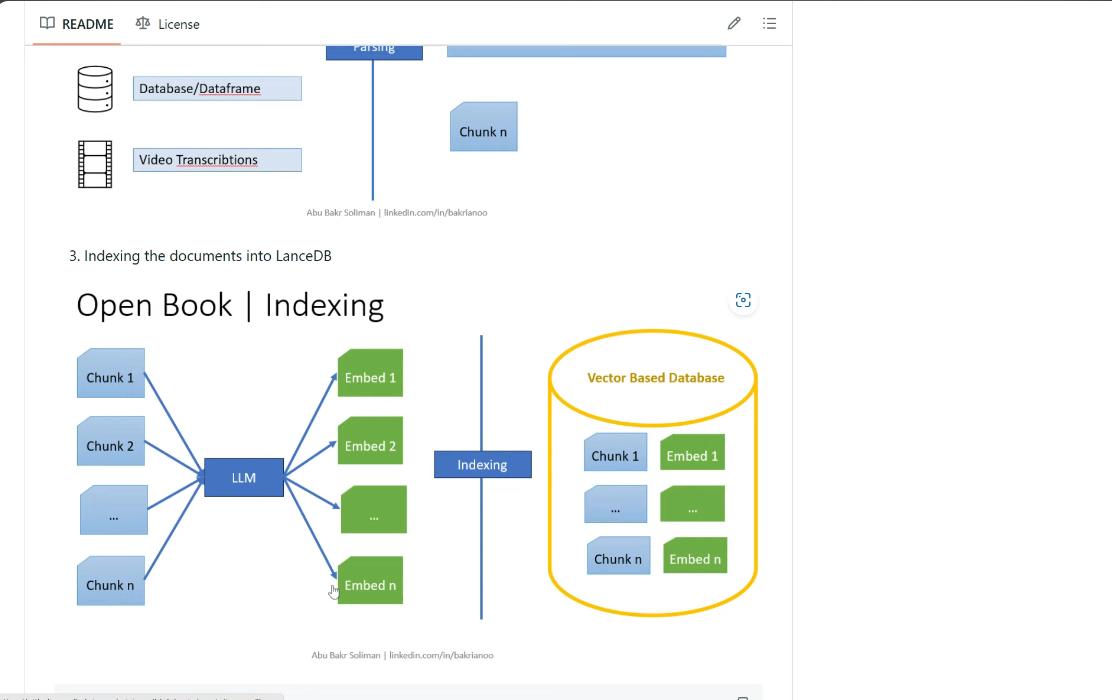

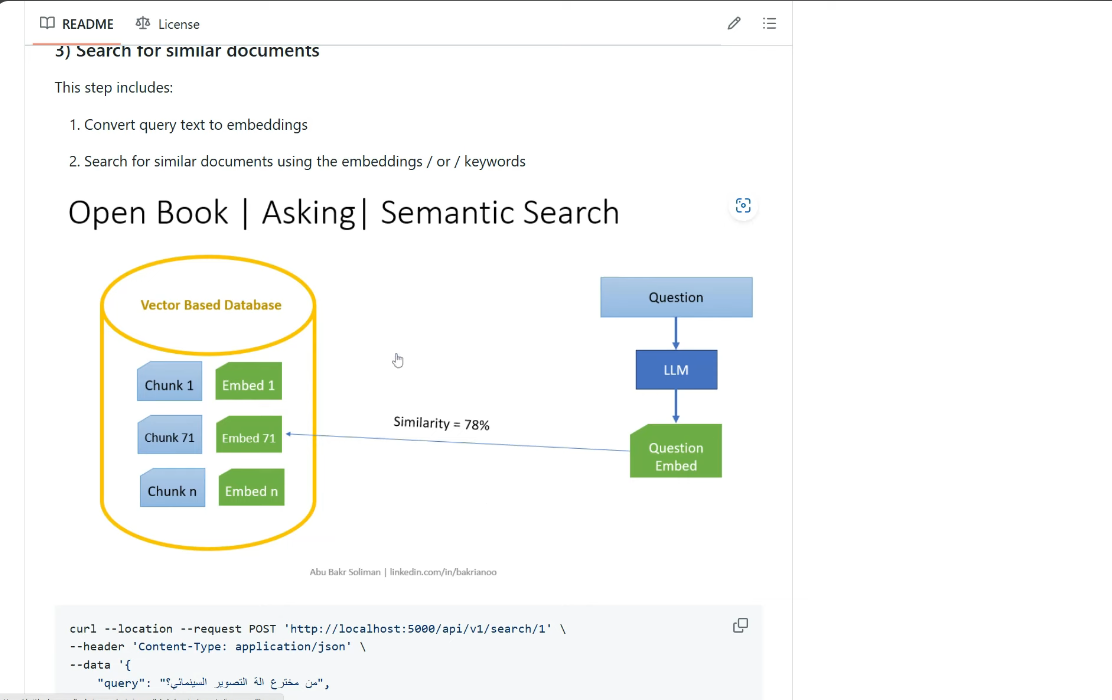